In [1]:
import os

print(os.getcwd())

d:\triazine_qspr_project\notebooks


In [2]:
import pandas as pd

df = pd.read_csv("../data/triazine_data.csv")
df

,compound_id,compound_name,smiles
0,Tz-Ph,"3-phenyl-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2
1,Tz-2OH,"3-(2-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2O
2,Tz-4Cl,"3-(4-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(Cl)cc2
3,Tz-tBu,"3-(4-tert-butylphenyl)-5,6-dimethyl-1,2,4-tria...",Cc1nnc(nc1(C))c2ccc(C(C)(C)C)cc2
4,Tz-4NO2,"3-(4-nitrophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc([N+](=O)[O-])cc2
5,Tz-4OH,"3-(4-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(O)cc2
6,Tz-2Cl,"3-(2-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2Cl
7,Tz-4Py,"3-(4-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccncc2
8,Tz-2Py,"3-(2-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ncccc2
9,Bis-Tz,"2,6-bis-(5,6-dimethyl-1,2,4-triazinyl)pyridine",CC1=NC(C2=NC(C3=NC(C)=C(C)N=N3)=CC=C2)=NN=C1C


In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

descriptor_list = []

for index, row in df.iterrows():
    compound_id = row["compound_id"]
    compound_name = row["compound_name"]
    smiles = row["smiles"]

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        print("Invalid SMILES:", compound_id, smiles)
        continue

    descriptor_data = {
        "compound_id": compound_id,
        "compound_name": compound_name,
        "smiles": smiles,
        "MolWt": round(Descriptors.MolWt(mol), 2),
        "LogP": round(Crippen.MolLogP(mol), 2),
        "TPSA": round(rdMolDescriptors.CalcTPSA(mol), 2),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "AromaticRings": Lipinski.NumAromaticRings(mol),
    }

    descriptor_list.append(descriptor_data)

descriptor_df = pd.DataFrame(descriptor_list)
descriptor_df


,compound_id,compound_name,smiles,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings
0,Tz-Ph,"3-phenyl-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2,185.23,2.16,38.67,0,3,1,2
1,Tz-2OH,"3-(2-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2O,201.23,1.86,58.90,1,4,1,2
2,Tz-4Cl,"3-(4-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(Cl)cc2,219.68,2.81,38.67,0,3,1,2
3,Tz-tBu,"3-(4-tert-butylphenyl)-5,6-dimethyl-1,2,4-tria...",Cc1nnc(nc1(C))c2ccc(C(C)(C)C)cc2,241.34,3.45,38.67,0,3,1,2
4,Tz-4NO2,"3-(4-nitrophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc([N+](=O)[O-])cc2,230.23,2.06,81.81,0,5,2,2
5,Tz-4OH,"3-(4-hydroxyphenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccc(O)cc2,201.23,1.86,58.90,1,4,1,2
6,Tz-2Cl,"3-(2-chlorophenyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccccc2Cl,219.68,2.81,38.67,0,3,1,2
7,Tz-4Py,"3-(4-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ccncc2,186.22,1.55,51.56,0,4,1,2
8,Tz-2Py,"3-(2-pyridyl)-5,6-dimethyl-1,2,4-triazine",Cc1nnc(nc1(C))c2ncccc2,186.22,1.55,51.56,0,4,1,2
9,Bis-Tz,"2,6-bis-(5,6-dimethyl-1,2,4-triazinyl)pyridine",CC1=NC(C2=NC(C3=NC(C)=C(C)N=N3)=CC=C2)=NN=C1C,293.33,2.02,90.23,0,7,2,3


In [4]:
descriptor_df.to_csv(
    "../results/triazine_dataset.csv",
    index=False
)

In [5]:
descriptor_df[['compound_id','LogP']].sort_values('LogP', ascending = False)


,compound_id,LogP
3,Tz-tBu,3.45
10,Tris-Tz,3.09
11,Thio-Tz,2.87
2,Tz-4Cl,2.81
6,Tz-2Cl,2.81
0,Tz-Ph,2.16
4,Tz-4NO2,2.06
9,Bis-Tz,2.02
1,Tz-2OH,1.86
5,Tz-4OH,1.86


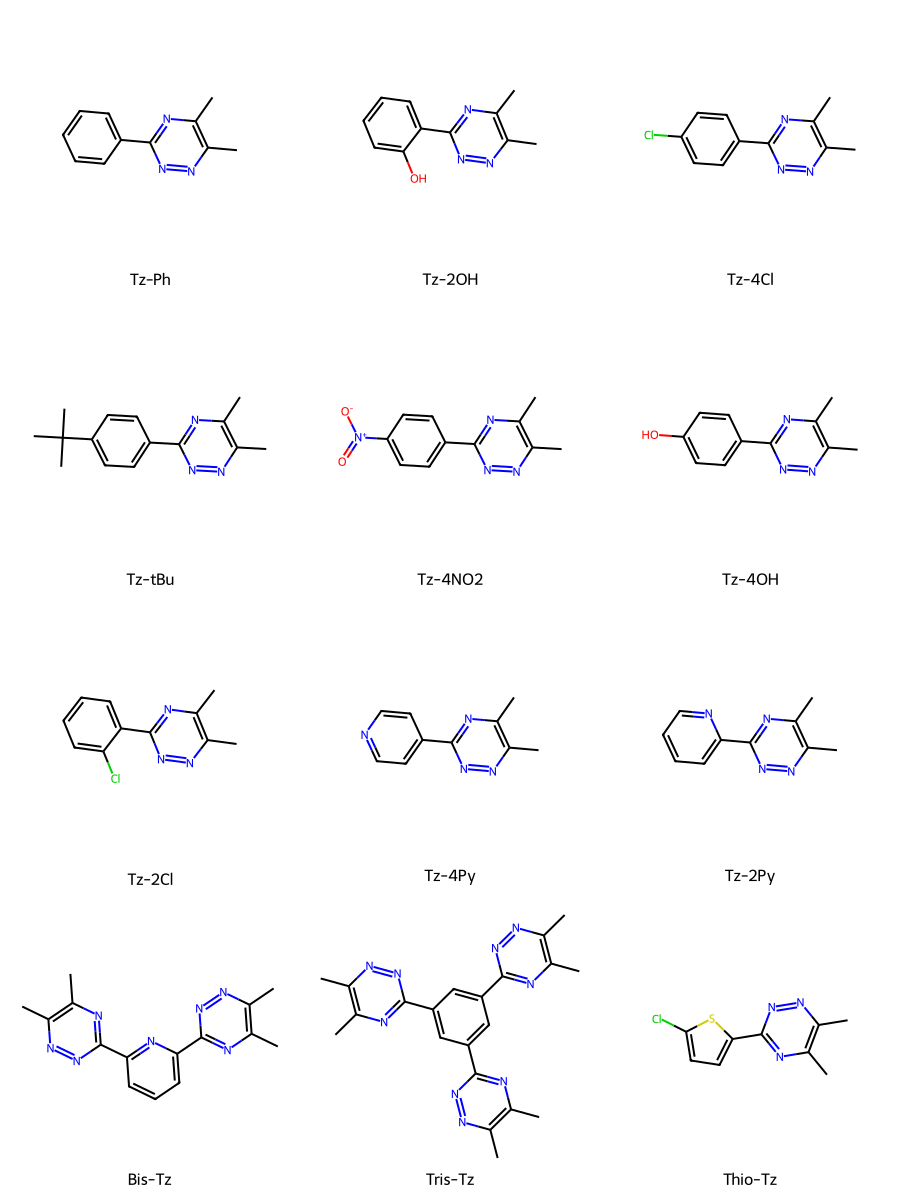

In [6]:
from rdkit.Chem import Draw
molecules_list = [Chem.MolFromSmiles(s) for s in descriptor_df['smiles']]
# Create legends from SMILES

a = descriptor_df['compound_id'].tolist()
# Generate grid image
img = Draw.MolsToGridImage(molecules_list, molsPerRow=3, legends = a, subImgSize=(300, 300))

display(img)

In [7]:
from rdkit import Chem
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit.Chem import rdMolDescriptors

descriptor_df["N_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==7
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

descriptor_df["O_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==8
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

descriptor_df["S_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum()==16
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

halogens = [9,17,35,53]

descriptor_df["Halogen_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum() in halogens
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

descriptor_df["Hetero_atoms"] = descriptor_df["smiles"].apply(
    lambda s: sum(
        atom.GetAtomicNum() not in [1,6]
        for atom in Chem.MolFromSmiles(s).GetAtoms()
    )
)

descriptor_df["Ring_count"] = descriptor_df["smiles"].apply(
    lambda s:
    rdMolDescriptors.CalcNumRings(
        Chem.MolFromSmiles(s)
    )
)

descriptor_df[["compound_id","N_atoms","O_atoms","S_atoms","Halogen_atoms","Hetero_atoms","Ring_count"]]

,compound_id,N_atoms,O_atoms,S_atoms,Halogen_atoms,Hetero_atoms,Ring_count
0,Tz-Ph,3,0,0,0,3,2
1,Tz-2OH,3,1,0,0,4,2
2,Tz-4Cl,3,0,0,1,4,2
3,Tz-tBu,3,0,0,0,3,2
4,Tz-4NO2,4,2,0,0,6,2
5,Tz-4OH,3,1,0,0,4,2
6,Tz-2Cl,3,0,0,1,4,2
7,Tz-4Py,4,0,0,0,4,2
8,Tz-2Py,4,0,0,0,4,2
9,Bis-Tz,7,0,0,0,7,3
